In [52]:
from pathlib import Path
import scipy.io as sio
import pandas as pd
import numpy as np
import matplotlib as plt

%load_ext autoreload
%autoreload 2

# TODO: 
# * normalize column names (i.e. sessFile -> dataDir)
# * look into LP03_03_pursuitRoot.mat corruption

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
# load region files 

data_dir = Path("/Users/may/pursuitSessionFiles")


def load_region_files(data_dir: Path, suffix: str):
    region_mats = {}
    for file in data_dir.glob(f"*{suffix}"):
        print(f"Loading: {file}")
        mat_data = sio.loadmat(file, spmatrix=False, squeeze_me=True)

        struct_dict = {}
        for key in mat_data['SL'].dtype.names:
            value = mat_data['SL'][key].squeeze()
            struct_dict[key] = value

        struct_name = file.stem
        region_mats[struct_name] = struct_dict

    return region_mats


region_directories = load_region_files(data_dir, 'SL.mat')
print("Extracted structures:", region_directories.keys())



Loading: /Users/may/pursuitSessionFiles/ca3SL.mat
Loading: /Users/may/pursuitSessionFiles/ca1SL.mat
Loading: /Users/may/pursuitSessionFiles/rscSL.mat
Extracted structures: dict_keys(['ca3SL', 'ca1SL', 'rscSL'])


/Users/may/miniconda/envs/Pursuit_Project/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [54]:
ca1_region_directory = pd.DataFrame(region_directories['ca1SL'])
ca1_region_directory.head()

,sessFile,tt,cellIndex,spkTimes,recNum,bsFile,blocks
0,KB09_20_pursuitRoot.mat,21,2,"[46.79045, 66.908075, 76.9185, 86.6525, 87.312...",6,KB09_20_BS_tt21c2.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]"
1,KB09_20_pursuitRoot.mat,21,3,"[0.000625, 0.015575, 0.050975, 0.060325, 0.071...",6,KB09_20_BS_tt21c3.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]"
2,KB09_20_pursuitRoot.mat,21,4,"[0.2124, 2.225525, 82.02395, 87.783875, 98.550...",6,KB09_20_BS_tt21c4.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]"
3,KB09_20_pursuitRoot.mat,21,5,"[14.360625, 14.379825, 41.87715, 42.164025, 46...",6,KB09_20_BS_tt21c5.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]"
4,KB09_20_pursuitRoot.mat,25,6,"[0.370475, 0.755575, 1.01435, 1.3245, 1.369425...",6,KB09_20_BS_tt25c6.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]"


In [55]:
#load pursuit files
suffix = 'pursuitRoot.mat'

pursuit_matrices = {}
ignore_keys = ['cells', 'spkTimes', 'Events']


for file in data_dir.glob(f"*{suffix}"):
    print(f"Loading: {file}")
    try:
        mat_data = sio.loadmat(file, spmatrix=False, squeeze_me=False)
    except:
        print(f"Unable to read {file}, skipping")
        continue
        
    struct_dict = {}
    for key in mat_data['session'].dtype.names:
        if key not in ignore_keys:
            value = mat_data['session'][0,0][key].squeeze()
    
            # Handle different data types
            if isinstance(value, np.ndarray):
                if value.ndim == 1:
                    value = value.astype(float).tolist()  # Convert 1D int array to float before list conversion
                elif value.ndim == 2:  # Expand 2D array into multiple columns
                    value = value.astype(float).tolist()  # Convert to a list of lists
                else:
                    raise ValueError(f"Unsupported array shape {value.shape} for key: {key}")
            else:
                value = [float(value)] if isinstance(value, int) else [value]  # Convert scalars to float
            
            struct_dict[key] = value  # Store in dictionary
    
    # Find the max length of any value
    max_len = max(len(v) if isinstance(v, list) else 1 for v in struct_dict.values())

    
    # Expand 2D arrays into separate columns dynamically
    expanded_dict = {}
    for key, value in struct_dict.items():
        if isinstance(value[0], list):  # Check if first element is a list (2D structure)
            for i in range(len(value[0])):  # Iterate over columns of 2D array
                expanded_dict[f"{key}_{i+1}"] = [
                    float(row[i]) if len(row) > i else np.nan for row in value
                ]
        else:
            # Convert integers to float before padding
            value = np.array(value, dtype=float)
            expanded_dict[key] = np.pad(value, (0, max_len - len(value)), constant_values=np.nan)
    
    struct_name = file.name
    pursuit_matrices[struct_name] = expanded_dict

Loading: /Users/may/pursuitSessionFiles/KB20_12_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_07_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB10_20_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP06_30_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP03_20_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB09_23_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP06_29_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP03_04_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP06_14_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB10_04_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_23_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB09_40_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB20_04_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_08_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_35_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/

In [56]:
pursuit_df = {
    filename: pd.DataFrame(file_data)
    for filename, file_data in pursuit_matrices.items()
}

pursuit_df['KB20_12_pursuitRoot.mat'].head()

,time,ind,ratPos_1,ratPos_2,laserPos_1,laserPos_2,ratVel,ratAcc,laserVel,laserAcc,...,laserBearingHD,centerDist,centerBearingMD,centerBearingHD,spkTable_1,spkTable_2,spkTable_3,spkTable_4,spkTable_5,spkTable_6
0,0.016667,1.0,177.695272,56.124961,NaN,NaN,20.459515,216.299997,9.154508e-12,1.084539e-11,...,NaN,66.050785,-1.199580,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1,0.033334,2.0,177.492655,55.922343,NaN,NaN,16.902984,215.132368,9.375474e-12,9.714661e-12,...,NaN,65.938896,-1.156703,NaN,0.0,0.0,0.0,1.0,0.0,0.0
2,0.050001,3.0,177.330562,55.679203,NaN,NaN,13.424213,212.258188,9.581305e-12,7.321996e-12,...,NaN,65.880961,-1.089322,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,0.066668,4.0,177.203202,55.575000,NaN,NaN,10.109205,207.670472,9.751049e-12,3.554880e-12,...,NaN,65.803028,-0.972072,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,0.083335,5.0,177.087421,55.494596,NaN,NaN,7.138728,201.359994,9.861847e-12,1.701152e-12,...,NaN,65.726948,-0.751346,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
ca1_region_directory['FE1_start'] = ca1_region_directory.blocks.apply(lambda x: x[0][0])
ca1_region_directory['FE1_end'] = ca1_region_directory.blocks.apply(lambda x: x[0][1])
ca1_region_directory['Pursuit_start'] = ca1_region_directory.blocks.apply(lambda x: x[1][0])
ca1_region_directory['Pursuit_end'] = ca1_region_directory.blocks.apply(lambda x: x[1][1])
ca1_region_directory['FE2_start'] = ca1_region_directory.blocks.apply(lambda x: x[2][0])
ca1_region_directory['FE2_end'] = ca1_region_directory.blocks.apply(lambda x: x[2][1])



In [58]:
ca1_region_directory.head()

,sessFile,tt,cellIndex,spkTimes,recNum,bsFile,blocks,FE1_start,FE1_end,Pursuit_start,Pursuit_end,FE2_start,FE2_end
0,KB09_20_pursuitRoot.mat,21,2,"[46.79045, 66.908075, 76.9185, 86.6525, 87.312...",6,KB09_20_BS_tt21c2.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]",NaN,NaN,2803.0,98102.0,NaN,NaN
1,KB09_20_pursuitRoot.mat,21,3,"[0.000625, 0.015575, 0.050975, 0.060325, 0.071...",6,KB09_20_BS_tt21c3.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]",NaN,NaN,2803.0,98102.0,NaN,NaN
2,KB09_20_pursuitRoot.mat,21,4,"[0.2124, 2.225525, 82.02395, 87.783875, 98.550...",6,KB09_20_BS_tt21c4.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]",NaN,NaN,2803.0,98102.0,NaN,NaN
3,KB09_20_pursuitRoot.mat,21,5,"[14.360625, 14.379825, 41.87715, 42.164025, 46...",6,KB09_20_BS_tt21c5.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]",NaN,NaN,2803.0,98102.0,NaN,NaN
4,KB09_20_pursuitRoot.mat,25,6,"[0.370475, 0.755575, 1.01435, 1.3245, 1.369425...",6,KB09_20_BS_tt25c6.mat,"[[nan, nan], [2803.0, 98102.0], [nan, nan]]",NaN,NaN,2803.0,98102.0,NaN,NaN


In [59]:
pursuit_start = ca1_region_directory['Pursuit_start']
print(ca1_region_directory.Pursuit_start)

0      2803.0
1      2803.0
2      2803.0
3      2803.0
4      2803.0
        ...  
223    2752.0
224    2752.0
225    2752.0
226    2752.0
227    2752.0
Name: Pursuit_start, Length: 228, dtype: float64


In [60]:
pursuit_end = ca1_region_directory['Pursuit_end']
print(ca1_region_directory.Pursuit_end)

0      98102.0
1      98102.0
2      98102.0
3      98102.0
4      98102.0
        ...   
223    90471.0
224    90471.0
225    90471.0
226    90471.0
227    90471.0
Name: Pursuit_end, Length: 228, dtype: float64


In [61]:
print(ca1_region_directory['sessFile'].unique())

['KB09_20_pursuitRoot.mat' 'KB09_22_pursuitRoot.mat'
 'KB09_23_pursuitRoot.mat' 'KB09_24_pursuitRoot.mat'
 'KB09_25_pursuitRoot.mat' 'KB09_26_pursuitRoot.mat'
 'KB10_09_pursuitRoot.mat' 'KB10_10_pursuitRoot.mat'
 'KB10_13_pursuitRoot.mat' 'KB10_15_pursuitRoot.mat'
 'LP03_01_pursuitRoot.mat' 'LP03_03_pursuitRoot.mat'
 'LP03_04_pursuitRoot.mat' 'LP03_05_pursuitRoot.mat'
 'LP03_06_pursuitRoot.mat' 'LP03_07_pursuitRoot.mat'
 'LP03_09_pursuitRoot.mat' 'LP03_10_pursuitRoot.mat'
 'LP03_12_pursuitRoot.mat' 'LP03_13_pursuitRoot.mat'
 'LP03_14_pursuitRoot.mat' 'LP03_15_pursuitRoot.mat'
 'LP03_17_pursuitRoot.mat' 'LP03_18_pursuitRoot.mat'
 'LP06_38_pursuitRoot.mat' 'LP06_39_pursuitRoot.mat'
 'LP06_42_pursuitRoot.mat' 'LP06_47_pursuitRoot.mat'
 'KB20_34_pursuitRoot.mat' 'KB20_35_pursuitRoot.mat'
 'KB20_40_pursuitRoot.mat' 'KB20_41_pursuitRoot.mat'
 'KB20_42_pursuitRoot.mat' 'KB20_44_pursuitRoot.mat']


In [62]:
#getting the start and end indicies for pursuit trials
def get_first_element(x):
    first_value = x.iloc[0]
    return first_value[0] if isinstance(first_value, (list, tuple, pd.Series)) else first_value
    
start_end_indices = ca1_region_directory.groupby("sessFile").agg({
    "Pursuit_start": get_first_element,
    "Pursuit_end": get_first_element
}).reset_index()

print(start_end_indices)

                   sessFile  Pursuit_start  Pursuit_end
0   KB09_20_pursuitRoot.mat         2803.0      98102.0
1   KB09_22_pursuitRoot.mat         2335.0      53952.0
2   KB09_23_pursuitRoot.mat         8836.0      68639.0
3   KB09_24_pursuitRoot.mat        47355.0      77774.0
4   KB09_25_pursuitRoot.mat         3405.0     111996.0
5   KB09_26_pursuitRoot.mat         4588.0      96483.0
6   KB10_09_pursuitRoot.mat         6153.0      73687.0
7   KB10_10_pursuitRoot.mat         4409.0      93455.0
8   KB10_13_pursuitRoot.mat         6451.0      78665.0
9   KB10_15_pursuitRoot.mat         5087.0      89200.0
10  KB20_34_pursuitRoot.mat         3317.0      84850.0
11  KB20_35_pursuitRoot.mat         2283.0     116946.0
12  KB20_40_pursuitRoot.mat         2627.0      87992.0
13  KB20_41_pursuitRoot.mat         2112.0      84054.0
14  KB20_42_pursuitRoot.mat         3929.0      96711.0
15  KB20_44_pursuitRoot.mat         2752.0      90471.0
16  LP03_01_pursuitRoot.mat         7009.0      

In [63]:
#define the start and end indices
pursuit_start = int(start_end_indices["Pursuit_start"].values[0])
pursuit_end = int(start_end_indices["Pursuit_end"].values[0])

#separate the code into trial blocks (FE= free explore)
FE1_block = pursuit_df['KB20_12_pursuitRoot.mat'].iloc[:pursuit_start] if pursuit_start > 0 else pd.DataFrame()
pursuit_block = pursuit_df['KB20_12_pursuitRoot.mat'].iloc[pursuit_start:pursuit_end +1]
FE2_block = pursuit_df['KB20_12_pursuitRoot.mat'].iloc[pursuit_end +1] if pursuit_end + 1 < len(pursuit_df['KB20_12_pursuitRoot.mat']) else pd.DataFrame()

print("\ncheck out the blocks")
print(pursuit_block)
print(FE1_block)
print(FE2_block)


check out the blocks
              time      ind    ratPos_1    ratPos_2  laserPos_1  laserPos_2  \
2803     46.734268   2804.0  108.078220  126.493677         NaN         NaN   
2804     46.750935   2805.0  108.094522  126.621768         NaN         NaN   
2805     46.767602   2806.0  108.122469  126.744037         NaN         NaN   
2806     46.784269   2807.0  108.162061  126.861648         NaN         NaN   
2807     46.800936   2808.0  108.213298  126.971108         NaN         NaN   
...            ...      ...         ...         ...         ...         ...   
98098  1635.016033  98099.0  113.196633   58.259428  140.162185   52.512785   
98099  1635.032700  98100.0  114.318014   58.116198  140.874839   52.449904   
98100  1635.049367  98101.0  115.460356   58.011397  141.608453   52.435930   
98101  1635.066034  98102.0  116.616671   57.931048  142.363027   52.456891   
98102  1635.082701  98103.0  117.797440   57.875154  143.145549   52.519772   

          ratVel      ratAcc 

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


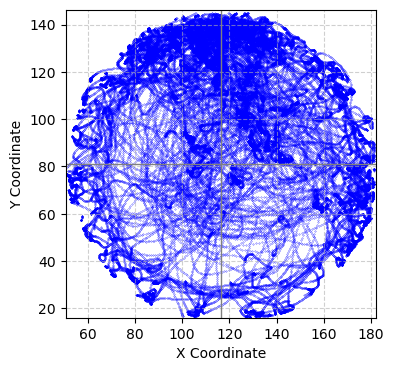

In [103]:
import matplotlib.pyplot as plt 

x = pursuit_block["ratPos_1"]
y = pursuit_block["ratPos_2"]

x_center = (x.max() + x.min()) / 2
y_center = (y.max() + y.min()) / 2

x_range = (x.max() - x.min()) / 2
y_range = (y.max() - y.min()) / 2
limit = max(x_range, y_range)  # Use max range to keep aspect equal

fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(x, y, c='blue', label="Points", s=0.05)

ax.set_xlim([x_center - limit, x_center + limit])
ax.set_ylim([y_center -limit, y_center +limit])

ax.set_aspect('equal', adjustable='datalim')

ax.axhline(y_center, color="gray", linewidth=1)
ax.axvline(x_center, color="gray", linewidth=1)
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")



plt.show()